# ALTRA Proteomics Validation: Aim 1

In [1]:
quiet_library <- function(...){
    suppressPackageStartupMessages(library(...))
}

In [2]:
quiet_library(hise)
quiet_library(dplyr)
quiet_library(tidyr)
quiet_library(tibble)
quiet_library(stringr)
quiet_library(stats)
quiet_library(qvalue)
quiet_library(ggplot2)
quiet_library(ggrepel)
quiet_library(RColorBrewer)

In [3]:
if(!dir.exists("/home/workspace/temp/output")) {
    dir.create("/home/workspace/temp/output")
}

outFiles <- list()

## Functions

In [4]:
# Function to plot manuscript figures

manuBoxplot <- function(df, poi, cols) {

    a <- df %>%
        filter(grepl(paste0(poi, collapse = '|'), Assay))

    ggplot(a, aes(x = Cluster, 
                  y = Calc..Conc..Mean)) + 
        geom_boxplot(outlier.shape = NA) + 
        geom_jitter(position = position_jitter(0.2), 
                    size = 2.5, 
                    aes(colour = RAStatus)) + 
        facet_wrap(~as.factor(Assay), 
                   scales = 'free', 
                   ncol = cols) + 
        scale_colour_manual(breaks = c('Healthy', 
                                       'Non-converter',
                                       'Converter',
                                       'ERA'),
                            labels = c('HC1', 
                                       'NONC',
                                       'CONV',
                                       'ERA'),
                            values = c('#4C8CBD',
                                       '#FFCD70',
                                       '#FF540A',
                                       '#840032'), 
                            name = 'Status') + 
        scale_x_discrete(breaks = c('C1', 
                                    'C6'),
                         labels = c('C1', 
                                    'C6'), 
                         limits = c('C1', 
                                    'C6')) + 
        theme_bw() + 
        labs(y = 'Plasma concentration\n(pg/mL)') + 
        theme(plot.title = element_text(size=12, face='bold', hjust=0.5), 
             #legend.position = c(0.85, 0.75),
             #legend.background = element_rect(colour = 'black', size = 0.5),
             legend.text = element_text(size=12), 
             legend.title = element_text(size=12),
             strip.text.x = element_text(size=14, face='bold'),
             axis.text.y = element_text(size=12),
             axis.text.x = element_text(size=12), 
             axis.title.y = element_text(size=12), 
             axis.title.x = element_text(size=12), 
             panel.grid.major = element_blank(),
             panel.grid.minor = element_blank())

}

In [5]:
# function for pval calculation

wcx <- function(df,prot) {

    a <- df %>%
        filter(Assay == prot)

    b <- wilcox.test(Calc..Conc..Mean ~ Cluster, 
                data = a, 
                alternative = 'two.sided', 
                paired = F, 
                exact = F)

    c <- as.data.frame(b$p.value) %>%
        rename(pval = `b$p.value`) %>%
        mutate(Assay = prot)            

}

## MSD Vplex Pro-Inflammatory

#### File info

In [6]:
# files can be found in the downloads section of our Data Apps website
# https://apps.allenimmunology.org/aifi/insights/ra-progression/downloads/

metadata <- '/home/workspace/temp/ALTRA_MSD/MSD_Metadata_for_Proteomics_Validation_Fig1E.csv'

msd_data <- '/home/workspace/temp/ALTRA_MSD/Vplex Plate data table EXP-00997 Pilot 3.csv'

#### Read in metadata

In [7]:
meta <- read.csv(metadata,
                    header = T, stringsAsFactors = F)

#### Read in data

In [8]:
data <- read.csv(msd_data, 
                 header = T, stringsAsFactors = F, skip = 1) %>%
    filter(!startsWith(Sample, 'S0'))

nrow(data)

[1] 290

#### Merge data and metadata

In [9]:
data_vpl <- meta %>%
    left_join(data, by = 'Well') %>%
    filter(Detection.Range != 'Below Fit Curve Range', 
           Cluster %in% c('C1', 'C6'))

nrow(data_vpl)

[1] 168

#### Stats

In [10]:
prot <- unique(data_vpl$Assay)

In [11]:
wcx_vpl <- lapply(prot, function(prot){
    wcx(data_vpl, prot)
    })


wcx_vpl_df <- bind_rows(wcx_vpl)

#### Visualization: IL-6, TNF Boxplots

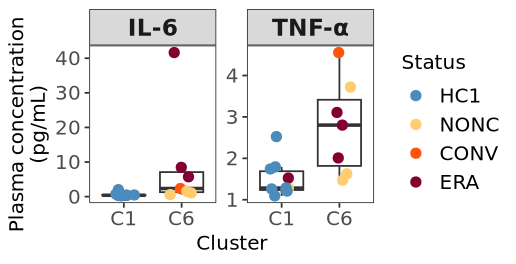

In [12]:
options(repr.plot.width = 4.3, repr.plot.height = 2.2) # default 7x7

prots <- c('IL-6', 'TNF')

p <- manuBoxplot(data_vpl, 
                 prots, 
                 2)

print(p)

In [13]:
ggsave(filename = 'Vplex_IL6_TNF.pdf', 
       #path = 'Figures',
       p,
       device = 'pdf', 
       width = 4, 
       height = 2.2, 
       units = 'in')

# warning due to symbol alpha in TNF-a. Ignore

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'TNF-α' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'TNF-α' in 'mbcsToSbcs': dot substituted for <b1>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'TNF-α' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'TNF-α' in 'mbcsToSbcs': dot substituted for <b1>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'TNF-α' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'TNF-α' in 'mbcsToSbcs': dot substituted for <b1>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$la

In [14]:
vplex <- data_vpl %>%
    filter(grepl(paste0(prots, collapse = '|'), Assay)) %>%
    select(Assay, 
           Sample.Kit.ID, 
           Cluster, 
           RAStatus,
           Calc..Conc..Mean) %>%
    arrange(Assay, Cluster)

nrow(vplex)

[1] 34

## MSD Splex Pro-Inflammatory

#### File info

In [15]:
# files can be found in the downloads section of our Data Apps website
# https://apps.allenimmunology.org/aifi/insights/ra-progression/downloads/

metadata <- '/home/workspace/temp/ALTRA_MSD/MSD_Metadata_for_Proteomics_Validation_Fig1E.csv'

msd_data <- '/home/workspace/temp/ALTRA_MSD/Splex EXP-00997 ALTRA MSD pilot4 Raw data.csv'

#### Read in metadata

In [16]:
meta <- read.csv(metadata,
                    header = T, stringsAsFactors = F)

#### Read in data

In [17]:
data <- read.csv(msd_data, 
                 header = T, stringsAsFactors = F, skip = 1) %>%
    filter(!startsWith(Sample, 'S0'))

nrow(data)

[1] 29

#### Merge data and metadata

In [18]:
data_spl <- meta %>%
    left_join(data, by = 'Well') %>%
    filter(Detection.Range != 'Below Fit Curve Range', 
           Cluster %in% c('C1', 'C6'))

nrow(data_spl)

[1] 17

In [19]:
prot <- unique(data_spl$Assay)

In [20]:
wcx_spl <- lapply(prot, function(prot){
    wcx(data_spl, prot)
    })


wcx_spl_df <- bind_rows(wcx_spl)

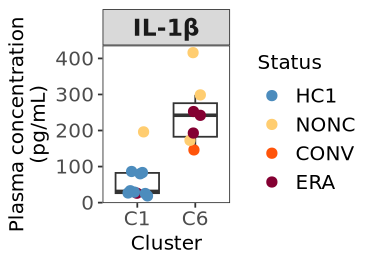

In [21]:
options(repr.plot.width = 3.1, repr.plot.height = 2.2) # default 7x7

prots <- c('IL-1')

p <- manuBoxplot(data_spl, 
                 prots, 
                 1)

print(p)

# note - units are fg/ml

In [22]:
ggsave(filename = 'Splex_IL1B.pdf', 
       #path = 'Figures',
       p,
       device = 'pdf', 
       width = 3, 
       height = 2.2, 
       units = 'in')

# warning due to symbol beta in IL-1B. Ignore

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'IL-1β' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'IL-1β' in 'mbcsToSbcs': dot substituted for <b2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'IL-1β' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'IL-1β' in 'mbcsToSbcs': dot substituted for <b2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'IL-1β' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'IL-1β' in 'mbcsToSbcs': dot substituted for <b2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$la

In [23]:
splex <- data_spl %>%
    #filter(Assay %in% prots) %>%
    select(Assay, 
           Sample.Kit.ID, 
           Cluster, 
           RAStatus,
           Calc..Conc..Mean) %>%
    arrange(Assay, Cluster)

nrow(splex)

[1] 17

## Legendplex

In [24]:
# files can be found in the downloads section of our Data Apps website
# https://apps.allenimmunology.org/aifi/insights/ra-progression/downloads/

metadata <- '/home/workspace/temp/ALTRA_MSD/MSD_Metadata_for_Proteomics_Validation_Fig1E.csv'

legend_data <- '/home/workspace/temp/ALTRA_Legendplex/Exp00997_ALTRA_Legendplex_CCL5.csv'

#### Read in metadata

In [25]:
meta <- read.csv(metadata,
                 header = T, stringsAsFactors = F)

#### Read in data

In [26]:
data <- read.csv(legend_data, 
                 header = T, stringsAsFactors = F) %>%
    mutate(Assay = 'CCL5') %>%
    rename('Calc..Conc..Mean' = 'Concentration')

nrow(data)

[1] 17

#### Merge data and metadata

In [27]:
data_lpl <- meta %>%
    left_join(data, by = 'Sample.Kit.ID') %>%
    filter(Cluster %in% c('C1', 'C6'))

nrow(data_lpl)

[1] 17

In [28]:
prot <- unique(data_lpl$Assay)

In [29]:
wcx_lpl <- lapply(prot, function(prot){
    wcx(data_lpl, prot)
    })


wcx_lpl_df <- bind_rows(wcx_lpl)

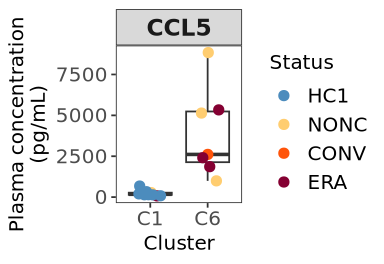

In [30]:
options(repr.plot.width = 3.2, repr.plot.height = 2.2) # default 7x7

prots <- c('CCL5')

p <- manuBoxplot(data_lpl, 
                 prots, 
                 1)

print(p)

In [31]:
ggsave(filename = 'LegendPlex_CCL5.pdf', 
       #path = 'Figures',
       p,
       device = 'pdf', 
       width = 3, 
       height = 2.2, 
       units = 'in')

In [32]:
legend <- data_lpl %>%
    #filter(Assay %in% prots) %>%
    select(Assay, 
           Sample.Kit.ID, 
           Cluster, 
           RAStatus,
           Calc..Conc..Mean) %>%
    arrange(Assay, Cluster)

nrow(legend)

[1] 17

## Adjust p values

In [33]:
bh_pvals <- wcx_vpl_df %>%
    bind_rows(wcx_spl_df) %>%
    bind_rows(wcx_lpl_df) %>%
    mutate(padj.bh = p.adjust(pval, method = 'BH'))

# note lower IL1B pval and FDR values are from higher sensitivity Splex assay

bh_pvals

pval,Assay,padj.bh
<dbl>,<chr>,<dbl>
0.0454360367,IFN-γ,0.09087207
0.1876827725,IL-10,0.25024370
0.3055070869,IL-12p70,0.36660850
0.1570523397,IL-13,0.23557851
0.0710097445,IL-1β,0.12173099
0.6238961960,IL-2,0.62389620
0.5914437399,IL-4,0.62389620
0.0029156363,IL-6,0.01166255
0.0039905825,IL-8,0.01197175


## Export data used to plot Fig 1E

In [34]:
Fig1E <- vplex %>%
    bind_rows(splex) %>%
    bind_rows(legend)

head(Fig1E)

,Assay,Sample.Kit.ID,Cluster,RAStatus,Calc..Conc..Mean
,<chr>,<chr>,<chr>,<chr>,<dbl>
1,IL-6,KT00420,C1,Non-converter,0.4099173
2,IL-6,KT04625,C1,ERA,0.3899649
3,IL-6,KT04671,C1,Healthy,0.4800131
4,IL-6,KT04905,C1,Healthy,0.3691715
5,IL-6,KT04652,C1,Healthy,0.3891961
6,IL-6,KT04115,C1,Healthy,0.2098072


In [35]:
out_Prots <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_MSD_Legendplex_Proteomics_Validation_Fig1E.csv"
)

write.csv(
    Fig1E, 
    out_Prots,
    row.names = TRUE
)

outFiles <- c(outFiles, out_Prots)

In [36]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] RColorBrewer_1.1-3 ggrepel_0.9.5      ggplot2_3.5.1      qvalue_2.34.0     
[5] stringr_1.5.1      tibble_3.2.1       tidyr_1.3.1        dplyr_1.1.4       
[9] hise_2.16.0       

loaded via a namespace (and not attached):
 [1] gtable_0.3.5      jsonlite_1.8.8    compiler_4.3.3    crayon_1.5.3     
 [5] Rcpp_